## 1. Operaciones Vectoriales y Matriciales (NumPy)


Producto escalar (a . b): -5.32
Multiplicación punto a punto: [  3.1    3.    -1.1  -16.32   6.  ]

Matriz Transpuesta A^T:
 [[ 2.   4.   7.3]
 [-1.   1.5 -0.9]
 [-3.  -2.5  0.2]]

Demostración NumPy:
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
round: [-2.  1.  2.  4.]
ceil: [-1.  2.  3.  4.]
floor: [-2.  1.  2.  3.]

Elemento Fila 1, Columna 3: -3.0
Segunda fila de A: [ 4.   1.5 -2.5]
Dimensiones de A: (3, 3)


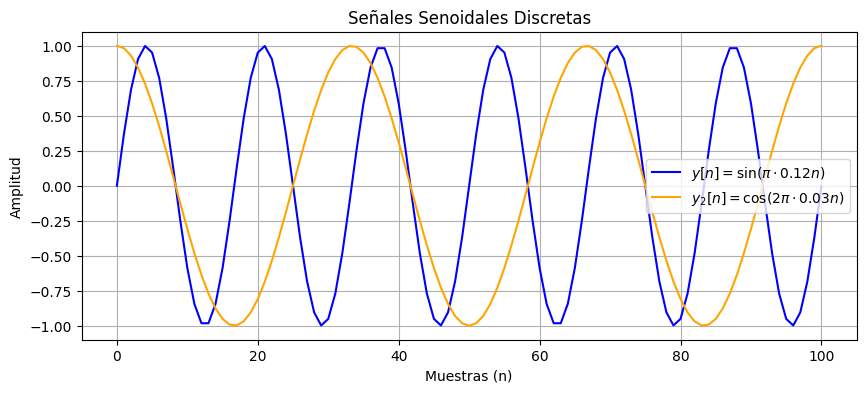

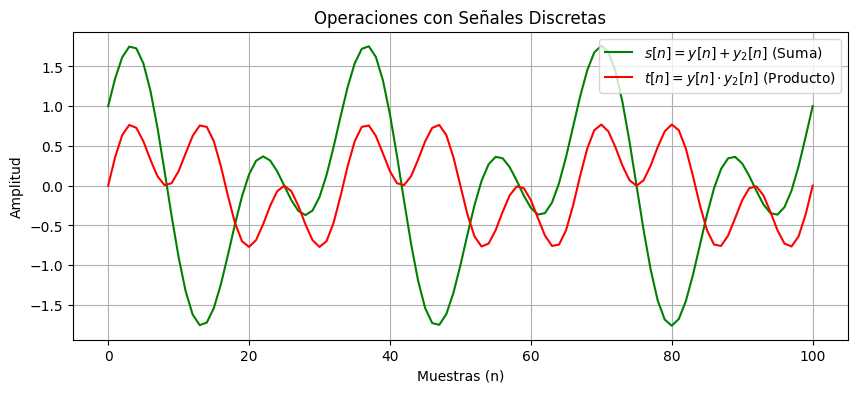

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Vectores
a = np.array([3.1, 1, -0.5, -3.2, 6])
b = np.array([1, 3, 2.2, 5.1, 1])

# Multiplicación escalar (Producto punto dot product)
# Para realizar producto escalar a.b, los vectores deben ser arrays de NumPy o usarse np.dot().
producto_escalar = np.dot(a, b)
print(f"Producto escalar (a . b): {producto_escalar}")

# Multiplicación elemento a elemento
producto_punto_a_punto = a * b
print(f"Multiplicación punto a punto: {producto_punto_a_punto}")

# Matriz A
A = np.array([
    [2, -1, -3],
    [4, 1.5, -2.5],
    [7.3, -0.9, 0.2]
])

AT = A.T
print("\nMatriz Transpuesta A^T:\n", AT)

# Funciones de NumPy
# np.ones: Genera un arreglo lleno de unos.
# np.round: Redondea al entero/decimal más cercano.
# np.ceil: Redondea hacia arriba (techo).
# np.floor: Redondea hacia abajo (piso).

arr_ones = np.ones((2, 3))
arr_ejemplo = np.array([-1.7, 1.2, 2.5, 3.8])

print("\nDemostración NumPy:")
print("ones:\n", arr_ones)
print("round:", np.round(arr_ejemplo))
print("ceil:", np.ceil(arr_ejemplo))
print("floor:", np.floor(arr_ejemplo))

# Accesos e inspección de A
elem_1_3 = A[0, 2] # Fila 1 (índice 0), Columna 3 (índice 2)
segunda_fila = A[1, :]
dimensiones = A.shape

print(f"\nElemento Fila 1, Columna 3: {elem_1_3}")
print(f"Segunda fila de A: {segunda_fila}")
print(f"Dimensiones de A: {dimensiones}")

# Señales Senoidales
n = np.arange(0, 101)
y1_n = np.sin(np.pi * 0.12 * n)
y2_n = np.cos(2 * np.pi * 0.03 * n)

s_n = y1_n + y2_n
t_n = y1_n * y2_n

# Gráfica 1: y[n] y y2[n]
plt.figure(figsize=(10, 4))
plt.plot(n, y1_n, label=r'$y[n] = \sin(\pi \cdot 0.12 n)$', color='blue')
plt.plot(n, y2_n, label=r'$y_2[n] = \cos(2\pi \cdot 0.03 n)$', color='orange')
plt.title('Señales Senoidales Discretas')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica 2: s[n] y t[n]
plt.figure(figsize=(10, 4))
plt.plot(n, s_n, label=r'$s[n] = y[n] + y_2[n]$ (Suma)', color='green')
plt.plot(n, t_n, label=r'$t[n] = y[n] \cdot y_2[n]$ (Producto)', color='red')
plt.title('Operaciones con Señales Discretas')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

## 2. Generación y Visualización de Señales Discretas

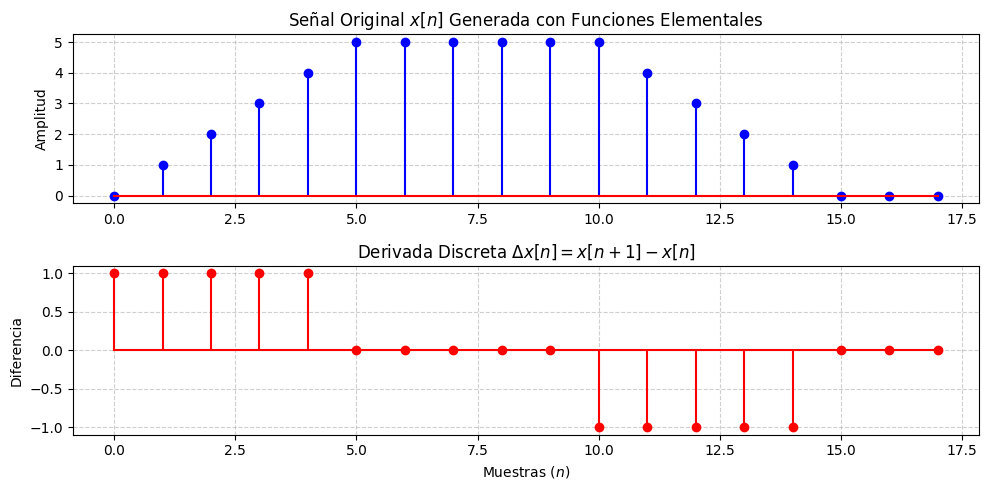

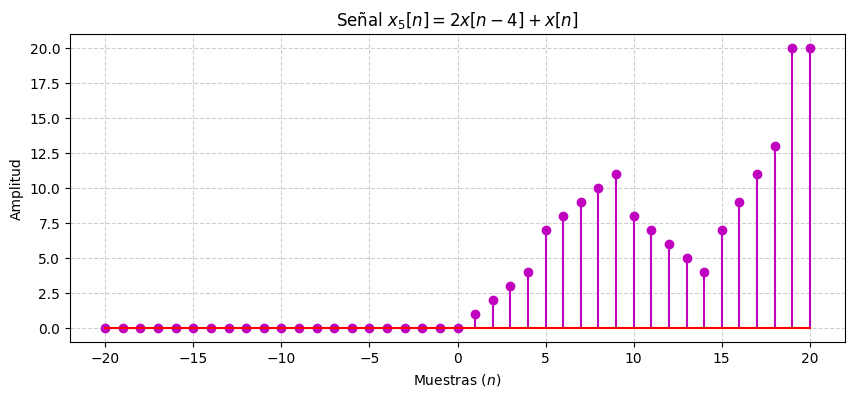

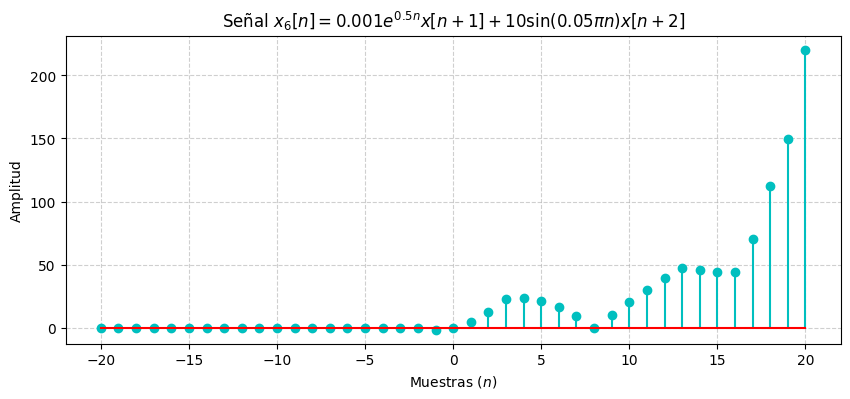

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# funciones elementales
def impseq(n0, n1, n2):
    """Impulso unitario delta(n - n0) en el intervalo [n1, n2]"""
    n = np.arange(n1, n2 + 1)
    x = (n - n0) == 0
    return [x.astype(int), n]

def stepseq(n0, n1, n2):
    """Escalón unitario u(n - n0) en el intervalo [n1, n2] (Ítem p)"""
    n = np.arange(n1, n2 + 1)
    x = (n - n0) >= 0
    return [x.astype(int), n]

def rampseq(n0, n1, n2, m=1):
    """Rampa r(n - n0) con pendiente m en el intervalo [n1, n2] (Ítem q)"""
    n = np.arange(n1, n2 + 1)
    x = m * (n - n0) * ((n - n0) >= 0)
    return [x, n]

def shift_signal(x_arr, k, n_range):
    """
    Función auxiliar para evaluar desplazamientos x[n - k]
    k > 0: Retardo (desplazamiento a la derecha)
    k < 0: Adelanto (desplazamiento a la izquierda)
    """
    y = np.zeros(len(n_range))
    for idx, val in enumerate(x_arr):
        target_n = idx + k
        pos = np.where(n_range == target_n)[0]
        if len(pos) > 0:
            y[pos[0]] = val
    return y

# senal por trozos y derivada discreta
n_tot = np.arange(0, 18)

# Generación de x[n] combinando escalones/rampas elementales
u0, _  = stepseq(0, 0, 17)
u5, _  = stepseq(5, 0, 17)
u10, _ = stepseq(10, 0, 17)
u15, _ = stepseq(15, 0, 17)

# x[n] = n*(u[n]-u[n-5]) + 5*(u[n-5]-u[n-10]) + (15-n)*(u[n-10]-u[n-15])
x_seg = n_tot * (u0 - u5) + 5 * (u5 - u10) + (15 - n_tot) * (u10 - u15)

# Derivada discreta mediante primera diferencia finita Delta x[n] = x[n+1] - x[n]
dx = np.zeros_like(x_seg)
dx[:-1] = np.diff(x_seg)

# Visualización
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.stem(n_tot, x_seg, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.title(r'Señal Original $x[n]$ Generada con Funciones Elementales')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(2, 1, 2)
plt.stem(n_tot, dx, linefmt='r-', markerfmt='ro', basefmt='r-')
plt.title(r'Derivada Discreta $\Delta x[n] = x[n+1] - x[n]$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Diferencia')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# evaluacion de operaciones en senales base
x_base = np.array([0,1,2,3,4,5,4,3,2,1,0,1,2,3,4,5,5,5,5,10,10,10,10])
n_eval = np.arange(-20, 21)

# Desplazamientos: x[n], x[n-4], x[n+1], x[n+2]
x_n        = shift_signal(x_base, 0, n_eval)
x_n_shift4 = shift_signal(x_base, 4, n_eval)    # Retardo x[n-4]
x_n_plus1  = shift_signal(x_base, -1, n_eval)   # Adelanto x[n+1]
x_n_plus2  = shift_signal(x_base, -2, n_eval)   # Adelanto x[n+2]

# Construccion de las señales especificadas
x5 = 2 * x_n_shift4 + x_n
x6 = (0.001 * np.exp(0.5 * n_eval) * x_n_plus1) + (10 * np.sin(0.05 * np.pi * n_eval) * x_n_plus2)

# Graficar x5[n]
plt.figure(figsize=(10, 4))
plt.stem(n_eval, x5, linefmt='m-', markerfmt='mo', basefmt='r-')
plt.title(r'Señal $x_5[n] = 2x[n-4] + x[n]$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Graficar x6[n]
plt.figure(figsize=(10, 4))
plt.stem(n_eval, x6, linefmt='c-', markerfmt='co', basefmt='r-')
plt.title(r'Señal $x_6[n] = 0.001e^{0.5n}x[n+1] + 10\sin(0.05\pi n)x[n+2]$')
plt.xlabel('Muestras ($n$)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Análisis de la Derivada Discreta
**Observación:**  
La derivada discreta se calculó mediante la primera diferencia finita hacia adelante ($\Delta x[n] = x[n+1] - x[n]$).

**¿Por qué no es exactamente la derivada del caso continuo?**
1. **Falta de Límite ($h \to 0$):** En el cálculo continuo, la derivada se define como $\lim_{h \to 0} \frac{f(t+h) - f(t)}{h}$. En señales discretas, la resolución temporal está fija por el intervalo de muestreo $T_s = 1$ ($h=1$), por lo que no es posible tomar un límite infinitesimal.
2. **Discontinuidades Puntuales:** En tiempo continuo, la derivada de un cambio de pendiente (esquina) genera un salto de tipo escalón, mientras que en tiempo discreto la transición genera impulsos puntuales aislados en el índice donde cambia la pendiente.

## 3. Carga, Procesamiento y Análisis de Datos con Pandas



In [9]:
import pandas as pd
import numpy as np

# 1. funcion estadistica de notas de alumnos
def calcular_estadisticas_notas(notas_dict):
    serie_notas = pd.Series(notas_dict)
    return pd.Series({
        'mínima': serie_notas.min(),
        'máxima': serie_notas.max(),
        'media': serie_notas.mean(),
        'desviación típica': serie_notas.std()
    })

# Demostración de la función
notas_alumnos = {'Ana': 4, 'Carlos': 3.8, 'Beatriz': 1.7, 'David': 5.0, 'Elena': 4.0}
print("=== 1. ESTADÍSTICAS DE NOTAS DEL CURSO ===")
print(calcular_estadisticas_notas(notas_alumnos))
print("\n" + "="*60 + "\n")


# 2. carga del archivo
nombre_archivo = "datos.csv"

try:
    # Carga de datos
    df = pd.read_csv(nombre_archivo, sep=';')
    print(f"✓ Archivo '{nombre_archivo}' cargado exitosamente.\n")

    # Inspeccion de la estructura original
    print("--- PRIMERAS 5 FILAS (df.head()) ---")
    display(df.head())

    print("\n--- ÚLTIMAS 5 FILAS (df.tail()) ---")
    display(df.tail())

    print("\n--- INFORMACIÓN GENERAL DE TIPOS DE DATOS (df.info()) ---")
    df.info()

    print("\n--- RESUMEN ESTADÍSTICO INICIAL (df.describe()) ---")
    display(df.describe())

    # 3. limpieza y calculo de IMC
    # Borrar columna residual "Unnamed: 0"
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    # Conversión numérica
    df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
    df['Height'] = pd.to_numeric(df['Height'], errors='coerce')

    # Cálculo del IMC: Peso (kg) / (Altura (m))^2
    df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)

    # Categorización según la OMS
    def categorizar_imc(imc):
        if pd.isna(imc):
            return np.nan
        elif imc < 18.5:
            return 'Bajo peso'
        elif 18.5 <= imc <= 24.9:
            return 'Normal'
        elif 25 <= imc <= 29.9:
            return 'Sobrepeso'
        else:
            return 'Obesidad'

    df['Categoria_IMC'] = df['BMI'].apply(categorizar_imc)

    print("\n" + "="*60)
    print("--- DATAFRAME CON IMC Y CATEGORÍAS ---")
    display(df.head())

except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{nombre_archivo}'.")

=== 1. ESTADÍSTICAS DE NOTAS DEL CURSO ===
mínima               1.700000
máxima               5.000000
media                3.700000
desviación típica    1.212436
dtype: float64


✓ Archivo 'datos.csv' cargado exitosamente.

--- PRIMERAS 5 FILAS (df.head()) ---


,Unnamed: 0,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932
1,3,Male,139,123,150,143.0,73.3,1038437
2,4,Male,133,129,128,172.0,68.8,965353
3,5,Female,137,132,134,147.0,65.0,951545
4,6,Female,99,90,110,146.0,69.0,928799



--- ÚLTIMAS 5 FILAS (df.tail()) ---


,Unnamed: 0,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
33,36,Female,133,129,128,153.0,66.5,948066
34,37,Male,140,150,124,144.0,70.5,949395
35,38,Female,88,86,94,139.0,64.5,893983
36,39,Male,81,90,74,148.0,74.0,930016
37,40,Male,89,91,89,179.0,75.5,935863



--- INFORMACIÓN GENERAL DE TIPOS DE DATOS (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  38 non-null     int64  
 1   Gender      38 non-null     object 
 2   FSIQ        38 non-null     int64  
 3   VIQ         38 non-null     int64  
 4   PIQ         38 non-null     int64  
 5   Weight      38 non-null     float64
 6   Height      38 non-null     float64
 7   MRI_Count   38 non-null     int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 2.5+ KB

--- RESUMEN ESTADÍSTICO INICIAL (df.describe()) ---


,Unnamed: 0,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,3.800000e+01
mean,20.973684,113.552632,112.131579,111.342105,151.052632,68.421053,9.067542e+05
std,11.600296,23.815391,22.939605,22.597867,23.478509,3.993790,7.256175e+04
min,1.000000,77.000000,71.000000,72.000000,106.000000,62.000000,7.906190e+05
25%,11.250000,90.250000,90.250000,89.250000,135.250000,66.000000,8.548115e+05
50%,21.000000,116.500000,113.000000,115.000000,146.500000,68.000000,9.053990e+05
75%,30.750000,135.000000,129.000000,128.000000,172.000000,70.375000,9.495405e+05
max,40.000000,144.000000,150.000000,150.000000,192.000000,77.000000,1.079549e+06



--- DATAFRAME CON IMC Y CATEGORÍAS ---


,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count,BMI,Categoria_IMC
0,Female,133,132,124,118.0,64.5,816932,283.636801,Obesidad
1,Male,139,123,150,143.0,73.3,1038437,266.150991,Obesidad
2,Male,133,129,128,172.0,68.8,965353,363.372093,Obesidad
3,Female,137,132,134,147.0,65.0,951545,347.928994,Obesidad
4,Female,99,90,110,146.0,69.0,928799,306.658265,Obesidad
